In [54]:
from pyspark.sql.session import SparkSession
import pyspark.sql.functions as F

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("HomeCreditDefaultRisk")
    .getOrCreate()
)

In [55]:
from pyspark.sql.types import NumericType, StringType
from pyspark.ml.feature import StringIndexer
import numpy as np
from math import floor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import catboost as cat
import joblib
import shap
shap.initjs()

In [56]:
train_df = spark.read.csv("../data/raw/application_train.csv", sep=',', header=True, inferSchema=True)
test_df = spark.read.csv("../data/raw/application_test.csv", sep=',', header=True, inferSchema=True)

train_df.show(10)


+----------+------+------------------+-----------+------------+---------------+------------+----------------+----------+-----------+---------------+---------------+--------------------+--------------------+--------------------+-----------------+--------------------------+----------+-------------+-----------------+---------------+-----------+----------+--------------+---------------+----------------+----------+----------+---------------+---------------+--------------------+---------------------------+--------------------------+-----------------------+--------------------------+--------------------------+---------------------------+----------------------+----------------------+-----------------------+--------------------+-------------------+-------------------+-------------------+--------------+----------------+---------------------------+------------------+--------------+-------------+-------------+-------------+-------------+------------+--------------------+--------------+------------

In [57]:
train_df.show(1, False, True)

-RECORD 0-----------------------------------------------------
 SK_ID_CURR                   | 100002                        
 TARGET                       | 1                             
 NAME_CONTRACT_TYPE           | Cash loans                    
 CODE_GENDER                  | M                             
 FLAG_OWN_CAR                 | N                             
 FLAG_OWN_REALTY              | Y                             
 CNT_CHILDREN                 | 0                             
 AMT_INCOME_TOTAL             | 202500.0                      
 AMT_CREDIT                   | 406597.5                      
 AMT_ANNUITY                  | 24700.5                       
 AMT_GOODS_PRICE              | 351000.0                      
 NAME_TYPE_SUITE              | Unaccompanied                 
 NAME_INCOME_TYPE             | Working                       
 NAME_EDUCATION_TYPE          | Secondary / secondary special 
 NAME_FAMILY_STATUS           | Single / not married   

In [58]:
for f in train_df.schema.fields:
    if not isinstance(f.dataType, (NumericType, StringType)):
        print(f.name, f.dataType)

In [ ]:
null_counts = train_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in train_df.columns])
null_counts.show()

In [ ]:
null_counts = train_df.select([
    (F.sum(F.col(c).isNull().cast('int')) / F.count('*')).alias(c)
    for c in train_df.columns
])

null_fractions = null_counts.collect()[0].asDict()
cols_to_keep = [c for c in null_fractions if null_fractions[c] <= 0.6]
cols_to_keep_test = [c for c in null_fractions if null_fractions[c] <= 0.6 if c != 'TARGET']

train_df_cleaned = train_df.select(*cols_to_keep)
test_df_cleaned = test_df.select(*cols_to_keep_test)

print(f'Кол-во столбцов до очистки (train): {len(train_df.columns)}')
print(f'Кол-во столбцов после очистки (train): {len(train_df_cleaned.columns)}')
print(f'Кол-во столбцов после очистки (test): {len(test_df_cleaned.columns)}')

Кол-во столбцов до очистки (train): 122
Кол-во столбцов после очистки (train): 105
Кол-во столбцов после очистки (test): 104


In [ ]:
numeric_cols = [f.name for f in train_df_cleaned.schema.fields if isinstance(f.dataType, NumericType) if f.name != 'TARGET']
cat_cols = [f.name for f in train_df_cleaned.schema.fields if isinstance(f.dataType, StringType)]

cat_values = {col: 'unknown' for col in cat_cols}
train_df_cleaned = train_df_cleaned.fillna(cat_values)
test_df_cleaned = test_df_cleaned.fillna(cat_values)

medians = {}
for col in numeric_cols:
    median_val = train_df_cleaned.approxQuantile(col, [0.5], 0.01)[0]
    if median_val is not None:
        medians[col] = median_val
    else:
        medians[col] = 0

train_df_cleaned = train_df_cleaned.fillna(medians)
test_df_cleaned = test_df_cleaned.fillna(medians)

null_counts = train_df_cleaned.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in train_df_cleaned.columns
]).collect()[0].asDict()

for col, count in null_counts.items():
    if count > 0:
        print(f'Column "{col}", {count} nulls')

In [ ]:
indexed_cols = [f'{col}_index' for col in cat_cols]

indexer = StringIndexer(
    inputCols=cat_cols,
    outputCols=indexed_cols,
    handleInvalid="keep"
)

model = indexer.fit(train_df_cleaned)
df_train_transformed = model.transform(train_df_cleaned)
df_test_transformed = model.transform(test_df_cleaned)

In [ ]:
df_train_transformed.select(indexed_cols).show(10)

+------------------------+-----------------+------------------+---------------------+---------------------+----------------------+-------------------------+------------------------+-----------------------+---------------------+--------------------------------+-----------------------+--------------------+------------------------+-------------------------+
|NAME_CONTRACT_TYPE_index|CODE_GENDER_index|FLAG_OWN_CAR_index|FLAG_OWN_REALTY_index|NAME_TYPE_SUITE_index|NAME_INCOME_TYPE_index|NAME_EDUCATION_TYPE_index|NAME_FAMILY_STATUS_index|NAME_HOUSING_TYPE_index|OCCUPATION_TYPE_index|WEEKDAY_APPR_PROCESS_START_index|ORGANIZATION_TYPE_index|HOUSETYPE_MODE_index|WALLSMATERIAL_MODE_index|EMERGENCYSTATE_MODE_index|
+------------------------+-----------------+------------------+---------------------+---------------------+----------------------+-------------------------+------------------------+-----------------------+---------------------+--------------------------------+-----------------------+--

In [ ]:
bureau = spark.read.csv('../data/raw/bureau.csv', header=True, inferSchema=True)
bureau.show(5)

+----------+------------+-------------+---------------+-----------+------------------+-------------------+-----------------+----------------------+------------------+--------------+-------------------+--------------------+----------------------+---------------+------------------+-----------+
|SK_ID_CURR|SK_ID_BUREAU|CREDIT_ACTIVE|CREDIT_CURRENCY|DAYS_CREDIT|CREDIT_DAY_OVERDUE|DAYS_CREDIT_ENDDATE|DAYS_ENDDATE_FACT|AMT_CREDIT_MAX_OVERDUE|CNT_CREDIT_PROLONG|AMT_CREDIT_SUM|AMT_CREDIT_SUM_DEBT|AMT_CREDIT_SUM_LIMIT|AMT_CREDIT_SUM_OVERDUE|    CREDIT_TYPE|DAYS_CREDIT_UPDATE|AMT_ANNUITY|
+----------+------------+-------------+---------------+-----------+------------------+-------------------+-----------------+----------------------+------------------+--------------+-------------------+--------------------+----------------------+---------------+------------------+-----------+
|    215354|     5714462|       Closed|     currency 1|       -497|                 0|             -153.0|           -153

In [ ]:
bureau_agg = bureau.groupBy('SK_ID_CURR').agg(
    F.count('*').alias('BUREAU_CNT_CREDITS'),
    F.sum(F.when(F.col('CREDIT_ACTIVE')=='Active', 1).otherwise(0)).alias('BUREAU_CNT_ACTIVE'),
    F.sum(F.when(F.col('CREDIT_ACTIVE')=='Bad debt', 1).otherwise(0)).alias('BUREAU_CNT_BAD_DEBT'),
    F.max('CREDIT_DAY_OVERDUE').alias('BUREAU_MAX_OVERDUE'),
    F.sum('AMT_CREDIT_SUM_DEBT').alias('BUREAU_TOTAL_DEBT'),
    F.sum('AMT_CREDIT_SUM_OVERDUE').alias('BUREAU_TOTAL_OVERDUE_DEBT'),
    F.mean('AMT_CREDIT_SUM').alias('BUREAU_AVG_CREDIT_SUM'),
    F.sum(F.when(F.col('DAYS_CREDIT')>-365, 1).otherwise(0)).alias('BUREAU_CNT_LAST_YEAR')
)

In [ ]:
prev = spark.read.csv('../data/raw/previous_application.csv', header=True, inferSchema=True)
prev.show(10)

+----------+----------+------------------+-----------+---------------+----------+----------------+---------------+--------------------------+-----------------------+---------------------------+----------------------+-----------------+---------------------+------------------------+----------------------+--------------------+-------------+--------------------+------------------+---------------+----------------+-------------------+--------------+-----------------+--------------------+----------------+--------------------+-----------+----------------+--------------------+------------------+--------------+-------------------------+-------------+----------------+-------------------------+
|SK_ID_PREV|SK_ID_CURR|NAME_CONTRACT_TYPE|AMT_ANNUITY|AMT_APPLICATION|AMT_CREDIT|AMT_DOWN_PAYMENT|AMT_GOODS_PRICE|WEEKDAY_APPR_PROCESS_START|HOUR_APPR_PROCESS_START|FLAG_LAST_APPL_PER_CONTRACT|NFLAG_LAST_APPL_IN_DAY|RATE_DOWN_PAYMENT|RATE_INTEREST_PRIMARY|RATE_INTEREST_PRIVILEGED|NAME_CASH_LOAN_PURPOSE|NAME

In [ ]:
prev_agg = prev.groupby('SK_ID_CURR').agg(
    F.count('*').alias('PREV_CNT'),
    F.sum(F.when(F.col('NAME_CONTRACT_STATUS')=='Approved', 1).otherwise(0)).alias('PREV_CNT_APPROVED'),
    F.sum(F.when(F.col('NAME_CONTRACT_STATUS')=='Refused', 1).otherwise(0)).alias('PREV_CNT_REFUSED'),
    F.avg('AMT_APPLICATION').alias('PREV_AVG_AMT_APPLICATION'),
    F.avg('AMT_CREDIT').alias('PREV_AVG_AMT_CREDIT'),
    F.avg('DAYS_DECISION').alias('PREV_AVG_DAYS_DECISION')
)

In [ ]:
inst = spark.read.csv('../data/raw/installments_payments.csv', header=True, inferSchema=True)
inst.show(5)


+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+
|SK_ID_PREV|SK_ID_CURR|NUM_INSTALMENT_VERSION|NUM_INSTALMENT_NUMBER|DAYS_INSTALMENT|DAYS_ENTRY_PAYMENT|AMT_INSTALMENT|AMT_PAYMENT|
+----------+----------+----------------------+---------------------+---------------+------------------+--------------+-----------+
|   1054186|    161674|                   1.0|                    6|        -1180.0|           -1187.0|       6948.36|    6948.36|
|   1330831|    151639|                   0.0|                   34|        -2156.0|           -2156.0|      1716.525|   1716.525|
|   2085231|    193053|                   2.0|                    1|          -63.0|             -63.0|       25425.0|    25425.0|
|   2452527|    199697|                   1.0|                    3|        -2418.0|           -2426.0|      24350.13|   24350.13|
|   2714724|    167756|                   1.0|                    2|        -1383.0

In [ ]:
inst_agg = inst.withColumn(
    'OVERDUE_DAYS',
    F.when(F.col('DAYS_INSTALMENT') < F.col('DAYS_ENTRY_PAYMENT'),
           F.col('DAYS_ENTRY_PAYMENT') - F.col('DAYS_INSTALMENT')
    ).otherwise(0)
).withColumn(
    'PAYMENT_RATIO',
    F.when(F.col('AMT_INSTALMENT')>0, F.col('AMT_PAYMENT') / F.col('AMT_INSTALMENT')).otherwise(0)
).groupBy('SK_ID_CURR').agg(
    F.count('*').alias('INST_PAYMENTS_CNT'),
    F.sum(F.when(F.col('DAYS_INSTALMENT') < F.col('DAYS_ENTRY_PAYMENT'), 1).otherwise(0)).alias('INST_CNT_OVERDUE'),
    F.avg('OVERDUE_DAYS').alias('INST_AVG_OVERDUE_DAYS'),
    F.avg('PAYMENT_RATIO').alias('INST_AVG_PAYMENT_RATIO'),
    F.sum(F.when(F.col('PAYMENT_RATIO') < 1, 1).otherwise(0)).alias('INST_CNT_UNDERPAYMENT')
)

In [ ]:
pos = spark.read.csv('../data/raw/POS_CASH_balance.csv', header=True, inferSchema=True)
pos.show(5)

+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|CNT_INSTALMENT|CNT_INSTALMENT_FUTURE|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+--------------+---------------------+--------------------+------+----------+
|   1803195|    182943|           -31|          48.0|                 45.0|              Active|     0|         0|
|   1715348|    367990|           -33|          36.0|                 35.0|              Active|     0|         0|
|   1784872|    397406|           -32|          12.0|                  9.0|              Active|     0|         0|
|   1903291|    269225|           -35|          48.0|                 42.0|              Active|     0|         0|
|   2341044|    334279|           -35|          36.0|                 35.0|              Active|     0|         0|
+----------+----------+--------------+--------------+---------------------+-----

In [ ]:
pos_agg = pos.groupBy('SK_ID_CURR').agg(
    F.count('*').alias('POS_CNT_RECORDS'),
    F.max('SK_DPD').alias('POS_MAX_DPD'),
    F.avg('SK_DPD').alias('POS_AVG_DPD'),
    F.sum(F.when(F.col('SK_DPD')>0, 1).otherwise(0)).alias('POS_CNT_DPD_OVERDUE'),
    F.sum('CNT_INSTALMENT_FUTURE').alias('POS_TOTAL_FUTURE_INSTALMENTS')
)

In [ ]:
ccb = spark.read.csv('../data/raw/credit_card_balance.csv', header=True, inferSchema=True)
ccb.show(5)

+----------+----------+--------------+-----------+-----------------------+------------------------+--------------------+--------------------------+------------------------+-----------------------+-------------------+-------------------------+------------------------+-------------+--------------------+------------------------+--------------------+--------------------------+------------------------+-------------------------+--------------------+------+----------+
|SK_ID_PREV|SK_ID_CURR|MONTHS_BALANCE|AMT_BALANCE|AMT_CREDIT_LIMIT_ACTUAL|AMT_DRAWINGS_ATM_CURRENT|AMT_DRAWINGS_CURRENT|AMT_DRAWINGS_OTHER_CURRENT|AMT_DRAWINGS_POS_CURRENT|AMT_INST_MIN_REGULARITY|AMT_PAYMENT_CURRENT|AMT_PAYMENT_TOTAL_CURRENT|AMT_RECEIVABLE_PRINCIPAL|AMT_RECIVABLE|AMT_TOTAL_RECEIVABLE|CNT_DRAWINGS_ATM_CURRENT|CNT_DRAWINGS_CURRENT|CNT_DRAWINGS_OTHER_CURRENT|CNT_DRAWINGS_POS_CURRENT|CNT_INSTALMENT_MATURE_CUM|NAME_CONTRACT_STATUS|SK_DPD|SK_DPD_DEF|
+----------+----------+--------------+-----------+------------------

In [ ]:
ccb_agg = ccb.groupBy('SK_ID_CURR').agg(
    F.count('*').alias('CC_CNT_RECORDS'),
    F.max('SK_DPD').alias('CC_MAX_DPD'),
    F.avg('SK_DPD').alias('CC_AVG_DPD'),
    F.sum(F.when(F.col('SK_DPD')>0, 1).otherwise(0)).alias('CC_CNT_DPD_OVERDUE'),
    F.sum('AMT_BALANCE').alias('CC_TOTAL_BALANCE')
)

In [ ]:
ccb_agg.show(5)

+----------+--------------+----------+--------------------+------------------+--------------------+
|SK_ID_CURR|CC_CNT_RECORDS|CC_MAX_DPD|          CC_AVG_DPD|CC_CNT_DPD_OVERDUE|    CC_TOTAL_BALANCE|
+----------+--------------+----------+--------------------+------------------+--------------------+
|    294744|            96|         0|                 0.0|                 0|          1428589.44|
|    348429|            38|         0|                 0.0|                 0|1.1382472530000001E7|
|    188986|            30|         0|                 0.0|                 0|1.0999690829999998E7|
|    393796|            25|         0|                 0.0|                 0|                 0.0|
|    119813|            96|         1|0.041666666666666664|                 4|         1384522.965|
+----------+--------------+----------+--------------------+------------------+--------------------+
only showing top 5 rows


In [ ]:
train_final = df_train_transformed
test_final = df_test_transformed
for agg_df in [bureau_agg, prev_agg, inst_agg, pos_agg, ccb_agg]:
    train_final = train_final.join(agg_df, on='SK_ID_CURR', how='left')
    test_final = test_final.join(agg_df, on='SK_ID_CURR', how='left')

string_cols = [f.name for f in train_final.schema.fields if isinstance(f.dataType, StringType)]
train_final = train_final.drop(*string_cols)
test_final = test_final.drop(*string_cols)

train_final = train_final.fillna(0)
test_final = test_final.fillna(0)

In [ ]:
null_train = train_final.select([
    F.sum(F.col(c).isNull().cast('int')).alias(c)
    for c in train_final.columns
]).collect()[0].asDict()

for col, val in null_train.items():
    if val > 0:
        print(col, val)

In [ ]:
train_final.select(F.when(F.col('DAYS_EMPLOYED') > 0, F.col('DAYS_EMPLOYED')).alias('DAYS_EMPLOYED')).show()

+-------------+
|DAYS_EMPLOYED|
+-------------+
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|       365243|
|         NULL|
|         NULL|
|       365243|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
|         NULL|
+-------------+
only showing top 20 rows


In [ ]:
train_final = train_final.withColumn('DEBT_TO_INCOME', F.when(F.col('AMT_INCOME_TOTAL')>0, F.col('AMT_CREDIT') / F.col('AMT_INCOME_TOTAL')).otherwise(0))
train_final = train_final.withColumn('AGE', ((-F.col('DAYS_BIRTH')) / 365).cast('int'))
train_final = train_final.withColumn('EMPLOYMENT_LEN', F.when(F.col('DAYS_EMPLOYED') < 0, ((-F.col('DAYS_EMPLOYED'))/365).cast('int')).otherwise(0))

test_final = test_final.withColumn('DEBT_TO_INCOME', F.when(F.col('AMT_INCOME_TOTAL')>0, F.col('AMT_CREDIT') / F.col('AMT_INCOME_TOTAL')).otherwise(0))
test_final = test_final.withColumn('AGE', ((-F.col('DAYS_BIRTH')) / 365).cast('int'))
test_final = test_final.withColumn('EMPLOYMENT_LEN', F.when(F.col('DAYS_EMPLOYED') < 0, ((-F.col('DAYS_EMPLOYED'))/365).cast('int')).otherwise(0))

In [ ]:
print(train_final.count())
print(test_final.count())


307511
48744


In [ ]:
features = [
    c for c in train_final.columns if c not in ['SK_ID_CURR', 'TARGET'] and c not in cat_cols
]

train_pd = train_final[features+['TARGET']].toPandas()
test_pd = test_final[features].toPandas()
X = train_pd.drop('TARGET', axis=1)
y = train_pd['TARGET']

X_test = test_pd

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=101)

scale = (y_train == 0).sum() / (y_train == 1).sum()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(f'NaN in X_train_scaled: {np.isnan(X_train_scaled).any()}')
print(f'NaN in y_train: {np.isnan(y_train).any()}')
print(f'NaN in X_val_scaled: {np.isnan(X_val_scaled).any()}')
print(f'NaN in y_train: {np.isnan(y_val).any()}')
print(f'NaN in X_test_scaled: {np.isnan(X_test_scaled).any()}')

NaN in X_train_scaled: False
NaN in y_train: False
NaN in X_val_scaled: False
NaN in y_train: False
NaN in X_test_scaled: False


In [ ]:
np.save('../data/processed/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/X_val_scaled.npy', X_val_scaled)
np.save('../data/processed/X_test_scaled.npy', X_test_scaled)

np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_val.npy', y_val.values)

test_ids = test_final.select('SK_ID_CURR').toPandas()
np.save('../data/processed/test_ids.npy', test_ids['SK_ID_CURR'].values)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    num_leaves=31,
    n_estimators=1000,
    learning_rate=0.1,
    scale_pos_weight=scale,
    subsample=0.7,
    colsample_bytree=0.7,
    subsample_freq=1,
    random_state=101,
    verbose=-1  
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50)]
)

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=101,
    early_stopping_rounds=50
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=0
)

cat_model = cat.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    subsample=0.7,
    early_stopping_rounds=50,
    auto_class_weights='Balanced',
    random_seed=101
)
cat_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=0
)

joblib.dump(lgb_model, '../models/lgb_model.joblib')
joblib.dump(xgb_model, '../models/xgb_model.joblib')
joblib.dump(cat_model, '../models/cat_model.joblib')

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.282462


['../models/cat_model.joblib']

In [ ]:
lgb_pred_proba = lgb_model.predict_proba(X_val)[:, 1]
xgb_pred_proba = xgb_model.predict_proba(X_val)[:, 1]
cat_pred_proba = cat_model.predict_proba(X_val)[:, 1]

best_lgb_f1 = 0
best_xgb_f1 = 0
best_cat_f1 = 0
best_lgb_thr = 0.5
best_xgb_thr = 0.5
best_cat_thr = 0.5
for thr in np.arange(0.1, 1.0, 0.1):
    lgb_preds = (lgb_pred_proba >= thr).astype(int)
    xgb_preds = (xgb_pred_proba >= thr).astype(int)
    cat_preds = (cat_pred_proba >= thr).astype(int)
    f1_lgb = f1_score(y_val, lgb_preds, average='macro')
    f1_xgb = f1_score(y_val, xgb_preds, average='macro')
    f1_cat = f1_score(y_val, cat_preds, average='macro')
    
    if f1_lgb > best_lgb_f1:
        best_lgb_f1 = f1_lgb
        best_lgb_thr = thr
    
    if f1_xgb > best_xgb_f1:
        best_xgb_f1 = f1_xgb
        best_xgb_thr = thr
    
    if f1_cat > best_cat_f1:
        best_cat_f1 = f1_cat
        best_cat_thr = thr

lgb_pred = (lgb_pred_proba >= best_lgb_thr).astype(int)
xgb_pred = (xgb_pred_proba >= best_xgb_thr).astype(int)
cat_pred = (cat_pred_proba >= best_cat_thr).astype(int)

print(f'Best threshold for LightGBM: {best_lgb_thr:.2f} (F1={best_lgb_f1:.4f})')
print(f'Best threshold for XGBoost: {best_xgb_thr:.2f} (F1={best_xgb_f1:.4f})')
print(f'Best threshold for CatBoost: {best_cat_thr:.2f} (F1={best_cat_f1:.4f})')

Best threshold for LightGBM: 0.20 (F1=0.4790)
Best threshold for XGBoost: 0.20 (F1=0.6246)
Best threshold for CatBoost: 0.70 (F1=0.6271)


In [ ]:
ensemble_proba = (xgb_pred_proba+cat_pred_proba) / 2
best_f1 = 0
best_thr = 0.5
for thr in np.linspace(0.1, 0.9, 20):
    preds = (ensemble_proba >= thr).astype(int)
    f1 = f1_score(y_val, preds, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

final_preds = (ensemble_proba >= best_thr).astype(int)
print(f'Best threshold: {best_thr:.2f}, (F1={best_f1:.4f})')
print(classification_report(y_val, final_preds))

Best threshold: 0.44, (F1=0.6277)
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     56538
           1       0.29      0.37      0.32      4965

    accuracy                           0.87     61503
   macro avg       0.62      0.65      0.63     61503
weighted avg       0.89      0.87      0.88     61503



In [ ]:
X_sample = X_train.sample(n=2000, random_state=101)

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer(X_sample)

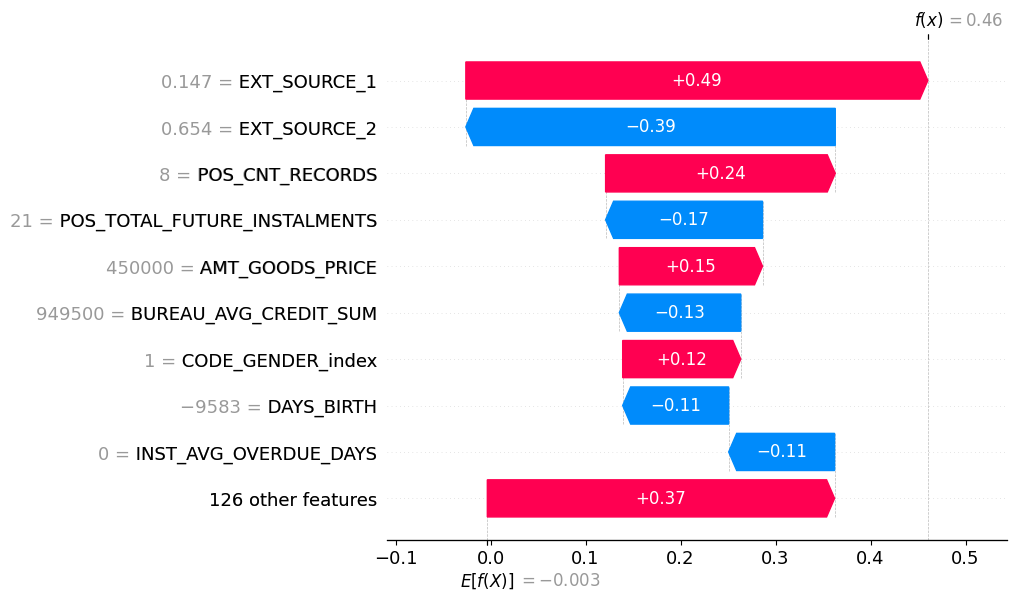

In [ ]:
shap.plots.waterfall(shap_values[0])

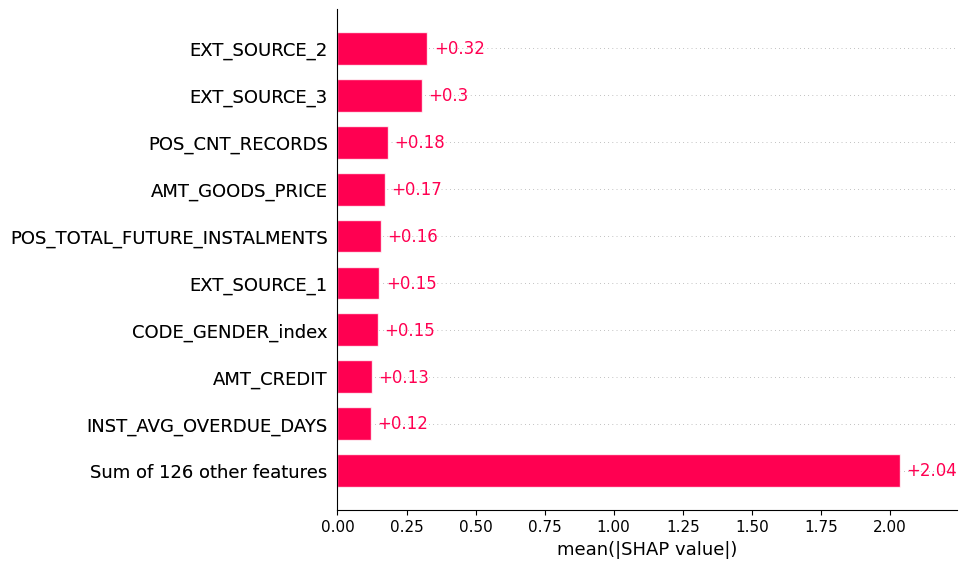

In [ ]:
shap.plots.bar(shap_values)

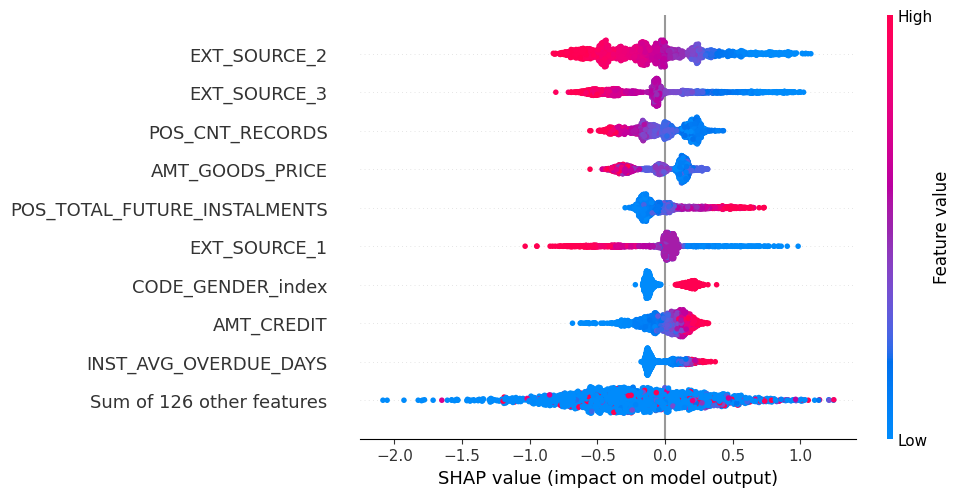

In [ ]:
shap.plots.beeswarm(shap_values)

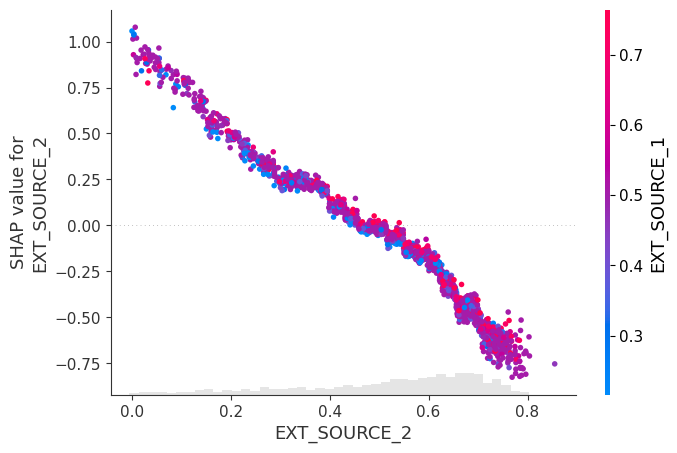

In [ ]:
shap.plots.scatter(shap_values[:, 'EXT_SOURCE_2'], color=shap_values)

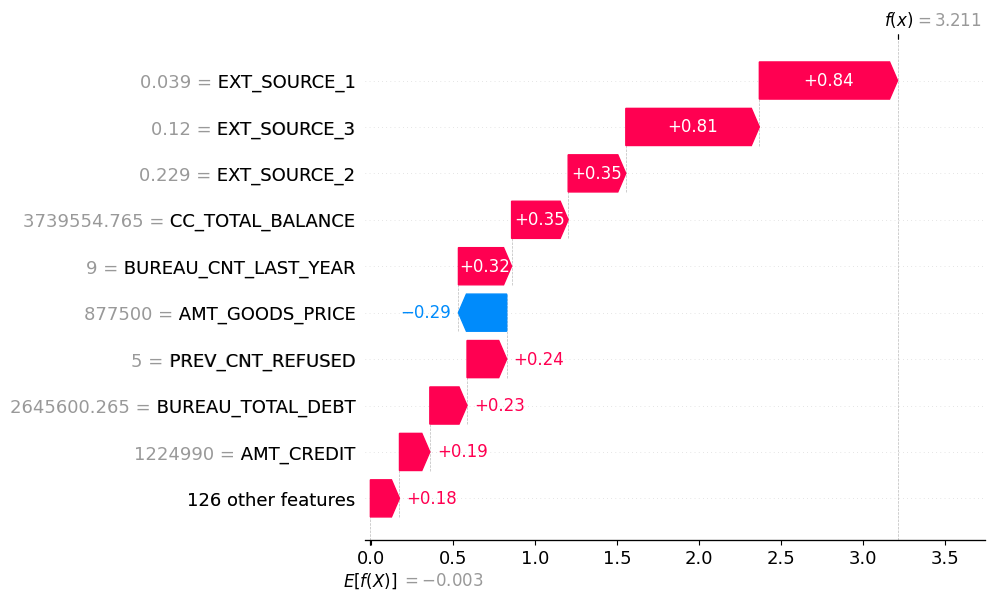

In [52]:
probs = cat_model.predict_proba(X_sample)[:, 1]
bad_idx = probs.argmax()

shap.plots.waterfall(shap_values[bad_idx])

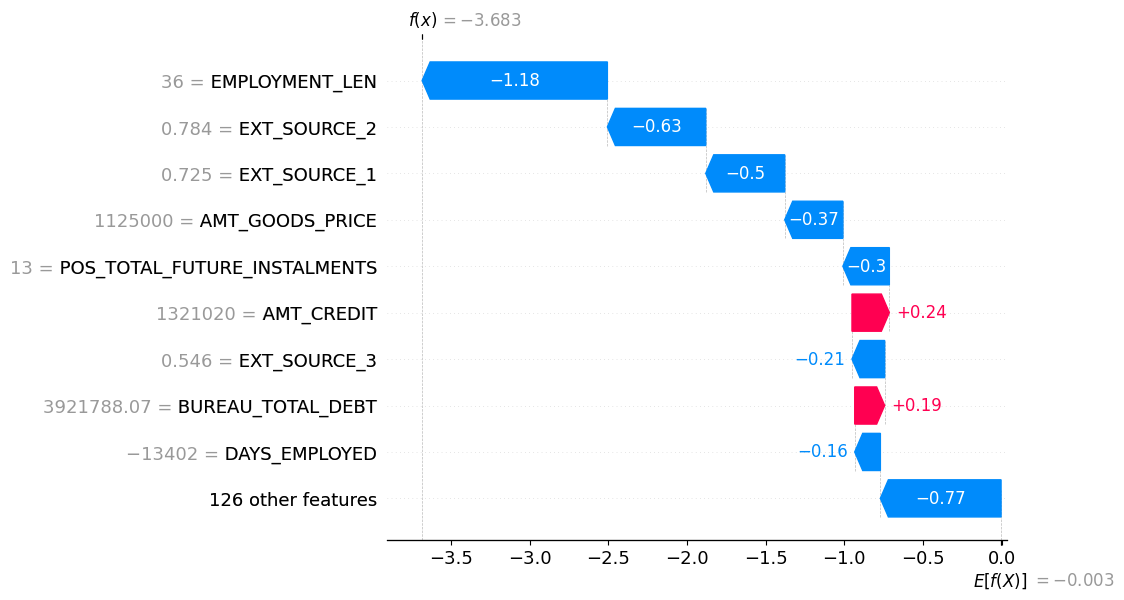

In [ ]:
probs1 = cat_model.predict_proba(X_sample)[:, 0]
good_idx = probs1.argmax()

shap.plots.waterfall(shap_values[good_idx])

In [ ]:
X_test_stressed = X_test.copy()
X_test_stressed['AMT_INCOME_TOTAL'] = X_test_stressed['AMT_INCOME_TOTAL']*0.8
X_test_stressed['DEBT_TO_INCOME'] = X_test_stressed['AMT_CREDIT'] / X_test_stressed['AMT_INCOME_TOTAL'] if X_test_stressed['AMT_INCOME_TOTAL'] > 0 else 0
X_test_stressed['DAYS_EMPLOYED'] = X_test_stressed['DAYS_EMPLOYED']*


train_final = train_final.withColumn('DEBT_TO_INCOME', F.when(F.col('AMT_INCOME_TOTAL')>0, F.col('AMT_CREDIT') / F.col('AMT_INCOME_TOTAL')).otherwise(0))
train_final = train_final.withColumn('AGE', ((-F.col('DAYS_BIRTH')) / 365).cast('int'))
train_final = train_final.withColumn('EMPLOYMENT_LEN', F.when(F.col('DAYS_EMPLOYED') < 0, ((-F.col('DAYS_EMPLOYED'))/365).cast('int')).otherwise(0))

test_final = test_final.withColumn('DEBT_TO_INCOME', F.when(F.col('AMT_INCOME_TOTAL')>0, F.col('AMT_CREDIT') / F.col('AMT_INCOME_TOTAL')).otherwise(0))
test_final = test_final.withColumn('AGE', ((-F.col('DAYS_BIRTH')) / 365).cast('int'))
test_final = test_final.withColumn('EMPLOYMENT_LEN', F.when(F.col('DAYS_EMPLOYED') < 0, ((-F.col('DAYS_EMPLOYED'))/365).cast('int')).otherwise(0))